# SECTION 1: CONFIGURATION & SETUP

In [1]:
import os
import math
import json
import time
import pickle
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
)
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("PlantHealth")

In [3]:
# ── Set seeds for reproducibility ──
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [4]:
# ── Device ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️  Device: cpu


In [5]:
DATASET_PATH = Path("/kaggle/input/datasets/karnamshyam/smartagricultureiot/Smart Agriculture and Plant Health Monitoring using IoT")
BASE_DIR     = Path("/kaggle/working")

# ── Derived Paths (auto-created) ──
DATASET_DIR   = DATASET_PATH
RESULTS_DIR   = BASE_DIR / "results"
CHECKPOINTS_DIR = BASE_DIR / "checkpoints"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "plots").mkdir(parents=True, exist_ok=True)

print(f"📁 Dataset path:   {DATASET_DIR}")
print(f"📁 Output base:    {BASE_DIR}")
print(f"📁 Results dir:    {RESULTS_DIR}")
print(f"📁 Checkpoints:    {CHECKPOINTS_DIR}")

📁 Dataset path:   /kaggle/input/datasets/karnamshyam/smartagricultureiot/Smart Agriculture and Plant Health Monitoring using IoT
📁 Output base:    /kaggle/working
📁 Results dir:    /kaggle/working/results
📁 Checkpoints:    /kaggle/working/checkpoints


In [6]:
# ── Sensor File Mappings ──
SENSOR_FILES = {
    "air_temp":       "Environment Temperature.xlsx",
    "humidity":       "Environment Humidity.xlsx",
    "light_lux":      "Environment Light Intensity.xlsx",
    "soil_moisture":  "Soil Moisture.xlsx",
    "soil_ph":        "Soil pH.xlsx",
    "soil_temp":      "Soil Temperature.xlsx",
    "water_tds":      "Water TDS.xlsx",
    "battery_volt":   "Solar Panel Battery Voltage.xlsx",
}
FEATURE_NAMES = list(SENSOR_FILES.keys())

In [7]:
# ── Data Pipeline Settings ──
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15
WINDOW_SIZE = 8

In [8]:
# ── Label Definitions ──
LABEL_MAP = {
    "Healthy": 0,
    "Hydraulic_Stress": 1,
    "Nutrient_Chemical_Stress": 2,
    "High_Disease_Risk": 3,
}
NUM_CLASSES = len(LABEL_MAP)
LABEL_NAMES = list(LABEL_MAP.keys())

In [9]:
# ── Agronomic Thresholds — Tuned for stability in small datasets
THRESHOLDS = {
    "hydraulic": {"soil_moisture_max": 63.0, "air_temp_min": 26.5},
    "nutrient":  {"ph_low": 6.0, "ph_high": 7.0, "tds_max": 120.0},
    "disease":   {"humidity_min": 94.0, "temp_low": 26.2, "temp_high": 26.4},
}

In [10]:
# ── Model Architecture ──
LSTM_BIDIRECTIONAL = True
DIM_FEEDFORWARD = 32
FC_HIDDEN_DIM = 128

In [11]:
# ── Training ──
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 50

D_MODEL = 8              
NUM_HEADS = 1
NUM_TRANSFORMER_LAYERS = 3

LSTM_HIDDEN_DIM = 8
LSTM_NUM_LAYERS = 1

TRANSFORMER_DROPOUT = 0.2

LSTM_DROPOUT = 0.2

# SECTION 2: DATA LOADING & MERGING

In [12]:
def detect_timestamp_col(df: pd.DataFrame) -> str:
    """Heuristically find the timestamp column."""
    for col in df.columns:
        if any(kw in col.lower() for kw in ["time", "date", "timestamp"]):
            return col
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return col
    try:
        pd.to_datetime(df.iloc[:, 0])
        return df.columns[0]
    except (ValueError, TypeError):
        pass
    raise ValueError(f"No timestamp column found. Columns: {list(df.columns)}")

In [13]:
def detect_value_col(df: pd.DataFrame, ts_col: str) -> str:
    """
    Select the correct sensor value column for IoT Excel files.

    Strategy:
    1. Drop timestamp column
    2. Ignore ID-like columns (entry_id, id, index)
    3. Prefer columns with domain keywords (ph, tds, temp, etc.)
    4. Fallback: use LAST numeric column (your dataset pattern)
    """

    # Step 1: remove timestamp column
    candidate_cols = [c for c in df.columns if c != ts_col]

    # Step 2: remove ID-like columns
    candidate_cols = [
        c for c in candidate_cols
        if not any(x in c.lower() for x in ["id", "entry", "index"])
    ]

    if not candidate_cols:
        raise ValueError("❌ No candidate columns found after filtering")

    # Step 3: prefer domain-specific names
    priority_keywords = [
        "ph", "tds", "temp", "temperature", "humidity",
        "moisture", "light", "lux", "voltage"
    ]

    for col in candidate_cols:
        if any(k in col.lower() for k in priority_keywords):
            return col

    # Step 4: fallback → last numeric column (IMPORTANT for your dataset)
    numeric_cols = [
        c for c in candidate_cols
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    if numeric_cols:
        return numeric_cols[-1] 

    # Step 5: final fallback
    return candidate_cols[-1]

In [14]:
def load_single_sensor(filepath: str, feature_name: str) -> pd.DataFrame:
    """
    Load one sensor Excel file into a time-indexed DataFrame.

    Handles multiple Excel layouts:
      - Standard: columns named with 'date'/'time' and a numeric value
      - Mendeley format: sensor name in cell A1, data in unnamed columns below
      - Raw: no headers, auto-detect date and value columns
    """
    # ── Strategy 1: Standard read ──
    try:
        df = pd.read_excel(filepath)
        ts_col = detect_timestamp_col(df)
        val_col = detect_value_col(df, ts_col)
        df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
        df = df.dropna(subset=[ts_col])
        df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
        result = df[[ts_col, val_col]].copy()
        result.columns = ["timestamp", feature_name]
        result = result.set_index("timestamp").sort_index()
        result = result[~result.index.duplicated(keep="first")]
        if len(result) > 0:
            return result
    except (ValueError, KeyError):
        pass

    # ── Strategy 2: Skip header row (sensor name as title in row 0) ──
    try:
        df = pd.read_excel(filepath, header=1)
        # Drop completely empty rows/columns
        df = df.dropna(how="all").dropna(axis=1, how="all")
        if len(df.columns) >= 2:
            ts_col = detect_timestamp_col(df)
            val_col = detect_value_col(df, ts_col)
            df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
            df = df.dropna(subset=[ts_col])
            df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
            result = df[[ts_col, val_col]].copy()
            result.columns = ["timestamp", feature_name]
            result = result.set_index("timestamp").sort_index()
            result = result[~result.index.duplicated(keep="first")]
            if len(result) > 0:
                return result
    except (ValueError, KeyError):
        pass

    # ── Strategy 3: Raw read — no header, auto-detect columns ──
    df = pd.read_excel(filepath, header=None)
    df = df.dropna(how="all").dropna(axis=1, how="all")
    print(f"    Raw columns for {feature_name}: {df.shape}, first values: {df.iloc[:3].values.tolist()}")

    # Find the first column that can be parsed as datetime
    ts_col_idx, val_col_idx = None, None
    for col_idx in range(df.shape[1]):
        try:
            parsed = pd.to_datetime(df[col_idx], errors="coerce")
            if parsed.notna().sum() > len(df) * 0.3:  # At least 30% valid dates
                ts_col_idx = col_idx
                break
        except Exception:
            continue

    # Find the first column with numeric data (not the timestamp column)
    for col_idx in range(df.shape[1]):
        if col_idx == ts_col_idx:
            continue
        numeric = pd.to_numeric(df[col_idx], errors="coerce")
        if numeric.notna().sum() > len(df) * 0.3:
            val_col_idx = col_idx
            break

    if ts_col_idx is None or val_col_idx is None:
        raise ValueError(
            f"Could not find timestamp+value columns in {filepath}. "
            f"Shape: {df.shape}, sample:\n{df.head(5)}"
        )

    result = pd.DataFrame({
        "timestamp": pd.to_datetime(df[ts_col_idx], errors="coerce"),
        feature_name: pd.to_numeric(df[val_col_idx], errors="coerce"),
    })
    result = result.dropna(subset=["timestamp"])
    result = result.set_index("timestamp").sort_index()
    result = result[~result.index.duplicated(keep="first")]
    return result

In [15]:
def load_and_merge_sensors():
    """Load all sensors, align timestamps, and preserve high-resolution data."""
    
    print("\n📂 Loading sensor data...")
    frames = []

    for feature_name, filename in SENSOR_FILES.items():
        filepath = DATASET_DIR / filename

        if not filepath.exists():
            print(f"  ⚠️ Missing: {filepath}")
            continue

        df = load_single_sensor(str(filepath), feature_name)

        print(f"  ✓ {feature_name:>15s}: {len(df):4d} readings | "
              f"{df.index.min()} → {df.index.max()}")

        # 🔥 IMPORTANT: sort + remove duplicates
        df = df.sort_index()
        df = df[~df.index.duplicated(keep="first")]

        frames.append(df)

    if not frames:
        raise ValueError("❌ No sensor data loaded!")

    # ✅ Merge using concat (best practice)
    merged = pd.concat(frames, axis=1)

    print(f"\n📊 After concat: {merged.shape}")

    # ✅ Sort time index
    merged = merged.sort_index()

    # ✅ Interpolate missing values (CRITICAL for async sensors)
    merged = merged.interpolate(method="time")

    # ✅ Forward + backward fill (edge cases)
    merged = merged.ffill().bfill()

    # 🚫 DO NOT RESAMPLE HERE
    # merged = merged.resample("15min").mean() 

    # 🚫 DO NOT DROP ALL NaNs
    # merged = merged.dropna()  

    print(f"\n✅ Final dataset: {merged.shape[0]} rows × {merged.shape[1]} features")
    print(f"   Time range: {merged.index.min()} → {merged.index.max()}")

    return merged

# SECTION 3: RULE-BASED LABEL GENERATION

In [16]:
def assign_label(row):
    """
    Simplified labeling logic:
    Priority: Disease > Nutrient > Hydraulic > Healthy
    """
    # 1. Disease Risk (High humidity + moderate temp)
    if row["humidity"] > THRESHOLDS["disease"]["humidity_min"]:
        if THRESHOLDS["disease"]["temp_low"] <= row["air_temp"] <= THRESHOLDS["disease"]["temp_high"]:
            return 3

    # 2. Nutrient/Chemical Stress (pH or TDS)
    if not (THRESHOLDS["nutrient"]["ph_low"] <= row["soil_ph"] <= THRESHOLDS["nutrient"]["ph_high"]):
        return 2
    if row["water_tds"] > THRESHOLDS["nutrient"]["tds_max"]:
        return 2

    # 3. Hydraulic Stress (Low moisture or Very high temp)
    if row["soil_moisture"] < THRESHOLDS["hydraulic"]["soil_moisture_max"]:
        return 1
    if row["air_temp"] > THRESHOLDS["hydraulic"]["air_temp_min"]:
        return 1

    # 0. Healthy (default)
    return 0

In [17]:
def generate_labels(df: pd.DataFrame) -> pd.Series:
    """Generate labels for every timestep."""
    print("\n🏷️  Generating health status labels...")
    labels = df.apply(assign_label, axis=1).astype(np.int64)
    labels.name = "label"

    total = len(labels)
    print("   Label distribution:")
    for idx in range(NUM_CLASSES):
        count = (labels == idx).sum()
        pct = 100 * count / total
        print(f"     {LABEL_NAMES[idx]:>28s}: {count:6d}  ({pct:5.1f}%)")

    return labels

In [18]:
def compute_class_weights(labels: pd.Series) -> np.ndarray:
    """Compute inverse-frequency class weights."""
    counts = np.bincount(labels.values.astype(np.int64), minlength=NUM_CLASSES)
    counts = np.maximum(counts, 1)
    weights = 1.0 / counts.astype(float)
    weights = weights / weights.sum() * NUM_CLASSES
    print(f"   Class weights: {dict(zip(LABEL_NAMES, weights.round(4)))}")
    return weights

# SECTION 4: PREPROCESSING

In [19]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical time-of-day encoding (sin/cos of hour)."""
    df = df.copy()
    hours = df.index.hour + df.index.minute / 60.0
    df["hour_sin"] = np.sin(2 * np.pi * hours / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hours / 24.0)
    return df

In [20]:
def preprocess_pipeline(
    df: pd.DataFrame, labels: pd.Series
) -> Tuple[Dict[str, Tuple[np.ndarray, np.ndarray]], StandardScaler, List[str]]:
    """
    Stratified split with embargo purging for small time-series datasets.
    
    Problem:
      With only 101 timesteps / 94 windows / 12 blocks / 4 classes,
      ANY temporal or group-based split results in splits missing entire
      classes — making training impossible.
    
    Solution (Purged Stratified Split):
      1. Stratified split ensures ALL classes appear in train/val/test.
      2. Embargo purge removes training windows that share timesteps
         with val/test windows (within WINDOW_SIZE distance).
      3. This prevents data leakage while maintaining class balance.
    
    This is the standard approach for tiny time-series classification
    datasets (cf. purged CV in financial ML literature).
    """
    from sklearn.model_selection import StratifiedShuffleSplit

    print("\n⚙️  Preprocessing...")

    # Feature engineering
    df = add_time_features(df)
    feature_columns = list(df.columns)

    # ── Step 1: Fit scaler on first 70% of data ──
    n_init = len(df)
    scaler_fit_end = int(n_init * TRAIN_RATIO)
    scaler = StandardScaler()
    scaler.fit(df.iloc[:scaler_fit_end].values)

    X_scaled = scaler.transform(df.values).astype(np.float32)
    y_scaled = labels.values.astype(np.int64)

    # ── Step 2: Create windows in chronological order ──
    print(f"   Creating windows (WINDOW_SIZE={WINDOW_SIZE})...")
    all_windows, all_labels = [], []
    for i in range(len(X_scaled) - WINDOW_SIZE + 1):
        all_windows.append(X_scaled[i : i + WINDOW_SIZE])
        all_labels.append(y_scaled[i + WINDOW_SIZE - 1])

    X = np.array(all_windows)
    y = np.array(all_labels)
    n_total = len(X)
    print(f"   Total windows: {n_total}")

    # ── Step 3: Stratified split (ensures all classes in every split) ──
    sss1 = StratifiedShuffleSplit(
        n_splits=1, test_size=(VAL_RATIO + TEST_RATIO), random_state=RANDOM_SEED
    )
    train_idx, temp_idx = next(sss1.split(X, y))

    test_frac = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    sss2 = StratifiedShuffleSplit(
        n_splits=1, test_size=test_frac, random_state=RANDOM_SEED
    )
    val_idx_rel, test_idx_rel = next(sss2.split(X[temp_idx], y[temp_idx]))
    val_idx = temp_idx[val_idx_rel]
    test_idx = temp_idx[test_idx_rel]

    # ── Step 4: Embargo purge — remove train windows near val/test ──
    # Two windows share timesteps if they're within WINDOW_SIZE indices.
    # For tiny datasets, a full embargo may remove ALL training data,
    # so we adaptively shrink it until ≥50% of training survives.
    val_test_set = set(val_idx) | set(test_idx)
    min_train_keep = max(len(train_idx) // 2, NUM_CLASSES * 2)

    for embargo in range(WINDOW_SIZE, 0, -1):
        forbidden = set()
        for idx in val_test_set:
            for offset in range(-embargo + 1, embargo):
                neighbor = idx + offset
                if 0 <= neighbor < n_total and neighbor not in val_test_set:
                    forbidden.add(neighbor)
        surviving = [i for i in train_idx if i not in forbidden]
        if len(surviving) >= min_train_keep:
            break
    else:
        # embargo=0: no purge, keep all training windows
        embargo = 0
        surviving = list(train_idx)

    train_idx_purged = np.array(surviving, dtype=np.int64)
    n_purged = len(train_idx) - len(train_idx_purged)
    print(f"   Embargo purge: removed {n_purged}/{len(train_idx)} train windows "
          f"(embargo={embargo} steps)")

    X_train, y_train = X[train_idx_purged], y[train_idx_purged]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    print(f"   After purge: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

    # ── Step 5: Augment training to recover from purge losses ──
    print(f"   Augmenting training set ({len(X_train)} windows)...")
    X_orig = X_train.copy()
    augmented_X = [X_train]
    augmented_y = [y_train]

    # More augmentation copies to compensate for purged samples
    n_aug_copies = max(3, 1 + n_purged // max(len(X_train), 1))
    for _ in range(n_aug_copies):
        X_jitter = X_orig + np.random.normal(0, 0.015, X_orig.shape)
        X_scale = X_orig * np.random.uniform(0.95, 1.05, size=(len(X_orig), 1, 1))
        augmented_X.extend([X_jitter, X_scale])
        augmented_y.extend([y_train, y_train])

    X_train = np.concatenate(augmented_X, axis=0)
    y_train = np.concatenate(augmented_y, axis=0)
    print(f"   After augmentation: train={len(X_train)} ({n_aug_copies} aug copies)")

    splits = {
        "train": (X_train, y_train),
        "val":   (X_val, y_val),
        "test":  (X_test, y_test),
    }

    for name, (feat, lab) in splits.items():
        dist = {int(k): int(v) for k, v in zip(*np.unique(lab, return_counts=True))}
        print(f"   {name:>5s}: {len(feat)} windows, labels={dist}")

    # Save scaler
    with open(CHECKPOINTS_DIR / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    return splits, scaler, feature_columns

# SECTION 5: PYTORCH DATASET & DATALOADERS

In [21]:
class PlantHealthDataset(Dataset):
    """Simple dataset for pre-computed windows."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    def get_all_labels(self):
        return self.y.numpy()

In [22]:
def create_dataloaders(
    splits: Dict[str, Tuple[np.ndarray, np.ndarray]],
    batch_size: int = BATCH_SIZE,
) -> Dict[str, DataLoader]:
    """Build DataLoaders with weighted sampling for training."""
    print("\n📦 Creating DataLoaders...")
    loaders = {}

    for name, (X, y) in splits.items():
        ds = PlantHealthDataset(X, y)

        if name == "train" and len(ds) > 0:
            # Weighted sampling to handle class imbalance
            all_labels = ds.get_all_labels()
            class_counts = np.bincount(all_labels, minlength=NUM_CLASSES)
            class_counts = np.maximum(class_counts, 1)
            sample_weights = 1.0 / class_counts[all_labels]
            sampler = WeightedRandomSampler(
                weights=torch.from_numpy(sample_weights).double(),
                num_samples=len(sample_weights),
                replacement=True,
            )
            loaders[name] = DataLoader(
                ds, batch_size=batch_size, sampler=sampler,
                num_workers=0, pin_memory=True, drop_last=(len(ds) >= batch_size),
            )
        elif name == "train" and len(ds) == 0:
            print(f"   ⚠️  WARNING: Training set is empty! (len(splits['train'][0])={len(X)} < WINDOW_SIZE={WINDOW_SIZE})")
            loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=False)
        else:
            if len(ds) == 0:
                 print(f"   ⚠️  WARNING: {name} set is empty! (len={len(X)})")
            loaders[name] = DataLoader(
                ds, batch_size=batch_size, shuffle=False,
                num_workers=0, pin_memory=True,
            )

        print(f"   {name:>5s}: {len(ds)} windows, {len(loaders[name])} batches")

    return loaders

# SECTION 6: MODEL ARCHITECTURE — HYBRID TRANSFORMER-LSTM

## 6a. Positional Encoding

In [23]:
class SinusoidalPositionalEncoding(nn.Module):
    """Standard sinusoidal PE from 'Attention Is All You Need'."""

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1), :])

## 6b. Multi-Head Self-Attention

In [24]:
class MultiHeadSelfAttention(nn.Module):
    """
    Custom MHA that exposes per-head attention weights for interpretability.
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(p=dropout)
        self._attention_weights = None

    def forward(self, x, return_attention=False):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = self.dropout(F.softmax(scores, dim=-1))
        self._attention_weights = attn_weights.detach()

        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)
        output = self.W_o(context)

        return (output, attn_weights) if return_attention else (output, None)

    def get_attention_weights(self):
        return self._attention_weights

## 6c. Transformer Encoder Block

In [25]:
class TransformerEncoderBlock(nn.Module):
    """Pre-Norm Transformer block: MHA + FFN with residual connections."""

    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, return_attention=False):
        residual = x
        attn_out, attn_weights = self.self_attn(self.norm1(x), return_attention=return_attention)
        x = residual + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, attn_weights

    def get_attention_weights(self):
        return self.self_attn.get_attention_weights()

## 6d. Hybrid Transformer-LSTM Model

In [26]:
class TransformerLSTM(nn.Module):
    """
    Hybrid Transformer-LSTM for multi-variate time-series classification.

    Architecture:
      Input → Linear Projection → Bi-LSTM → Positional Encoding
        → N × Transformer Blocks → Global Avg Pool → MLP → num_classes
    """

    def __init__(self, input_dim, d_model=D_MODEL, num_heads=NUM_HEADS,
                 num_transformer_layers=NUM_TRANSFORMER_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD,
                 lstm_hidden_dim=LSTM_HIDDEN_DIM,
                 lstm_num_layers=LSTM_NUM_LAYERS,
                 lstm_bidirectional=LSTM_BIDIRECTIONAL,
                 num_classes=NUM_CLASSES,
                 fc_hidden_dim=FC_HIDDEN_DIM,
                 dropout=TRANSFORMER_DROPOUT):
        super().__init__()
        self.d_model = d_model

        # 1. Input Projection
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # 2. Bi-directional LSTM
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=lstm_bidirectional,
            dropout=LSTM_DROPOUT if lstm_num_layers > 1 else 0.0,
        )
        lstm_out_dim = lstm_hidden_dim * (2 if lstm_bidirectional else 1)
        self.lstm_projection = nn.Sequential(
            nn.Linear(lstm_out_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # 3. Positional Encoding
        self.use_transformer = num_transformer_layers > 0
        if self.use_transformer:
            self.positional_encoding = SinusoidalPositionalEncoding(d_model, dropout=dropout)
            self.transformer_blocks = nn.ModuleList([
                TransformerEncoderBlock(d_model, num_heads, dim_feedforward, dropout)
                for _ in range(num_transformer_layers)
            ])
            self.final_norm = nn.LayerNorm(d_model)

        # 5. Classification Head (Simplified for tiny data)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, fc_hidden_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden_dim // 4, num_classes),
        )

        self._init_weights()
        total = sum(p.numel() for p in self.parameters())
        print(f"🧠 TransformerLSTM: {total:,} parameters")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_attention=False):
        x = self.input_projection(x)
        lstm_out, _ = self.lstm(x)
        x = self.lstm_projection(lstm_out)
        attention_maps = []
        if self.use_transformer:
            x = self.positional_encoding(x)
            for block in self.transformer_blocks:
                x, attn_w = block(x, return_attention=return_attention)
                if return_attention and attn_w is not None:
                    attention_maps.append(attn_w)
            x = self.final_norm(x)
        x = x.mean(dim=1)  # Global Average Pooling
        logits = self.classifier(x)

        result = {"logits": logits}
        if return_attention:
            result["attention"] = attention_maps
        return result

    def get_all_attention_weights(self):
        return [block.get_attention_weights() for block in self.transformer_blocks]

# SECTION 7: TRAINING LOOP

In [27]:
def compute_metrics(y_true, y_pred, y_prob=None):
    """Compute F1, Precision, Recall, confusion matrix, and PR curves."""
    metrics = {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_per_class": f1_score(y_true, y_pred, average=None, zero_division=0,
                                 labels=range(NUM_CLASSES)).tolist(),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_per_class": precision_score(y_true, y_pred, average=None, zero_division=0,
                                               labels=range(NUM_CLASSES)).tolist(),
        "recall_per_class": recall_score(y_true, y_pred, average=None, zero_division=0,
                                         labels=range(NUM_CLASSES)).tolist(),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES)).tolist(),
        "classification_report": classification_report(
            y_true, y_pred, target_names=LABEL_NAMES, zero_division=0, labels=range(NUM_CLASSES)),
    }

    if y_prob is not None:
        ap_per_class, pr_curves = [], {}
        for c in range(NUM_CLASSES):
            binary_true = (y_true == c).astype(int)
            if binary_true.sum() > 0:
                ap = average_precision_score(binary_true, y_prob[:, c])
                p, r, _ = precision_recall_curve(binary_true, y_prob[:, c])
                ap_per_class.append(ap)
                pr_curves[LABEL_NAMES[c]] = {"precision": p.tolist(), "recall": r.tolist()}
            else:
                ap_per_class.append(0.0)
                pr_curves[LABEL_NAMES[c]] = {"precision": [], "recall": []}
        metrics["average_precision_per_class"] = ap_per_class
        metrics["mean_average_precision"] = np.mean(ap_per_class)
        metrics["pr_curves"] = pr_curves

    return metrics

In [28]:
def train_model(model, train_loader, val_loader, class_weights,
                num_epochs=NUM_EPOCHS, device=DEVICE):
    """
    Full training loop with early stopping on validation F1.
    """
    model = model.to(device)

    # Class-weighted loss
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {"train_loss": [], "train_f1": [], "train_accuracy": [],
               "val_loss": [], "val_f1": [], "val_accuracy": [], "lr": []}
    best_val_f1 = 0.0
    patience_counter = 0

    print(f"\n🚀 Starting training: {num_epochs} epochs")
    print(f"   Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
    print("=" * 70)

    for epoch in range(1, num_epochs + 1):
        # ── Train ──
        model.train()
        total_loss = 0.0
        all_preds, all_labels = [], []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:3d}/{num_epochs}", leave=False)
        for batch_x, batch_y in pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_x)["logits"]
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss = total_loss / len(all_preds)
        train_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        train_accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

        # ── Validate ──
        model.eval()
        val_loss = 0.0
        val_preds, val_labels, val_probs = [], [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)["logits"]
                loss = criterion(logits, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels.extend(batch_y.cpu().numpy())
                val_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())

        val_loss = val_loss / max(len(val_preds), 1)
        val_labels_arr = np.array(val_labels)
        val_preds_arr = np.array(val_preds)
        val_f1 = f1_score(val_labels_arr, val_preds_arr, average="macro", zero_division=0)
        val_acc = np.mean(val_labels_arr == val_preds_arr)
        lr = optimizer.param_groups[0]["lr"]
        # scheduler.step() # DISABLE scheduler for small data to prevent early decay

        # Record
        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_accuracy"].append(val_acc)
        history["lr"].append(lr)

        print(
            f"  Epoch {epoch:3d} | "
            f"Train Loss={train_loss:.4f} F1={train_f1:.4f} Train Acc={train_accuracy:.4f} | "
            f"Val Loss={val_loss:.4f} F1={val_f1:.4f} Val Acc={val_acc:.4f} | "
            f"LR={lr:.2e}"
        )

        # Early stopping
        if val_f1 > best_val_f1 or epoch == 1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "val_f1": val_f1,
                "val_loss": val_loss,
            }, CHECKPOINTS_DIR / "best_model.pt")
            if epoch > 1:
                print(f"  ↑ New best model (F1={best_val_f1:.4f}) saved!")
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"\n⏹️  Early stopping at epoch {epoch} (patience={EARLY_STOPPING_PATIENCE})")
                break

    # Save last model + history
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                "val_f1": val_f1}, CHECKPOINTS_DIR / "last_model.pt")
    with open(RESULTS_DIR / "training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"\n✅ Training complete! Best Val F1: {best_val_f1:.4f}")
    return history

# SECTION 8: EVALUATION

In [29]:
@torch.no_grad()
def evaluate_model(model, test_loader, device=DEVICE):
    """Full test-set evaluation."""
    model.eval()
    model = model.to(device)
    all_preds, all_labels, all_probs = [], [], []

    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)["logits"]
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["accuracy"] = float(np.mean(y_true == y_pred))

    # Inference latency
    dummy = torch.randn(1, WINDOW_SIZE, model.input_projection[0].in_features, device=device)
    for _ in range(10):  # warmup
        model(dummy)
    latencies = []
    for _ in range(100):
        t0 = time.perf_counter()
        model(dummy)
        latencies.append((time.perf_counter() - t0) * 1000)
    metrics["latency_mean_ms"] = np.mean(latencies)
    metrics["latency_p95_ms"] = np.percentile(latencies, 95)

    # Print report
    print("\n" + "=" * 60)
    print("📋 TEST SET EVALUATION RESULTS")
    print("=" * 60)
    print(metrics["classification_report"])
    print(f"Accuracy:       {metrics['accuracy']:.4f}")
    print(f"F1 (macro):     {metrics['f1_macro']:.4f}")
    print(f"F1 (weighted):  {metrics['f1_weighted']:.4f}")
    print(f"Mean AP:        {metrics.get('mean_average_precision', 'N/A')}")
    print(f"Latency:        {metrics['latency_mean_ms']:.2f} ms (p95: {metrics['latency_p95_ms']:.2f} ms)")
    print("=" * 60)

    # Save
    with open(RESULTS_DIR / "classification_report.txt", "w") as f:
        f.write(metrics["classification_report"])
    np.save(RESULTS_DIR / "test_predictions.npy", y_pred)
    np.save(RESULTS_DIR / "test_true_labels.npy", y_true)
    np.save(RESULTS_DIR / "test_probabilities.npy", y_prob)

    return metrics, y_true, y_pred, y_prob

# SECTION 9: EXPLAINABILITY

In [30]:
!pip install captum

In [31]:
@torch.no_grad()
def extract_attention_maps(model, x, device=DEVICE):
    """Run forward pass and return attention weights from all layers."""
    model.eval()
    x = x.to(device)
    output = model(x, return_attention=True)
    return output.get("attention", [])

In [32]:
def compute_attention_feature_importance(model, x, feature_names, device=DEVICE):
    """Aggregate attention weights to estimate per-feature importance."""
    attn_maps = extract_attention_maps(model, x, device)
    if not attn_maps:
        return {name: 1.0 / len(feature_names) for name in feature_names}

    stacked = torch.stack(attn_maps)
    avg_attn = stacked.mean(dim=[0, 1, 2])
    pos_importance = avg_attn.sum(dim=0).cpu().numpy()
    pos_importance = pos_importance / pos_importance.sum()

    x_np = x.cpu().numpy().mean(axis=0)
    weighted = (x_np * pos_importance[:, np.newaxis]).sum(axis=0)
    importance = np.abs(weighted)
    importance = importance / (importance.sum() + 1e-8)

    return {name: float(imp) for name, imp in zip(feature_names[:len(importance)], importance)}

In [33]:
def compute_ig_attributions(model, x, target_class, device=DEVICE, n_steps=50):
    """
    Compute Integrated Gradients attributions.
    Falls back to gradient × input if Captum is not available.
    """
    try:
        from captum.attr import IntegratedGradients
        ig = IntegratedGradients(lambda inp: model(inp)["logits"])
        
        # Ensure target_class is a standard int
        if torch.is_tensor(target_class):
            target_class = target_class.item()
        
        x = x.to(device).requires_grad_(True)
        attr = ig.attribute(x, target=target_class, n_steps=n_steps,
                            return_convergence_delta=False)
        return attr.detach().cpu().numpy().squeeze(0)
    except Exception as e:
        print(f"  ⚠️  IG error: {str(e)[:50]}... using gradient fallback.")
        try:
            model.eval()
            x = x.to(device).detach().requires_grad_(True)
            output = model(x)["logits"]
            
            if torch.is_tensor(target_class):
                target_class = target_class.item()
            
            # Use specific logit for backprop
            # Handle out of bounds
            target_class = min(max(0, int(target_class)), output.size(1) - 1)
            
            logit = output[:, target_class]
            model.zero_grad()
            logit.backward()
            
            if x.grad is not None:
                grad = x.grad.detach().cpu().numpy().squeeze(0)
                return grad * x.detach().cpu().numpy().squeeze(0)
            else:
                return np.zeros(x.shape[1:])
        except Exception as e2:
            print(f"  ❌ Fallback failed: {e2}")
            return np.zeros(x.shape[1:])

In [34]:
def run_explainability(model, test_loader, feature_names, device=DEVICE,
                       max_samples=100):
    """Full explainability pipeline: attention + IG."""
    if len(test_loader) == 0:
        print("\n⚠️  SKIPPING explainability: Test loader is empty.")
        return {}, {}

    print("\n🔍 Running explainability analysis...")

    # Get a test batch
    try:
        batch_x, batch_y = next(iter(test_loader))
    except StopIteration:
        print("\n⚠️  SKIPPING explainability: Could not get batch from test loader.")
        return {}, {}

    # --- Attention Analysis ---
    print("   → Extracting attention maps...")
    attn_importance = compute_attention_feature_importance(model, batch_x, feature_names, device)

    print("   Attention-based feature importance:")
    for name, imp in sorted(attn_importance.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(imp * 50)
        print(f"     {name:>15s}: {bar} {imp:.4f}")

    # --- Integrated Gradients ---
    print("\n   → Computing Integrated Gradients...")
    model_device = next(model.parameters()).device
    all_attrs = []
    n = 0
    for bx, by in test_loader:
        for i in range(bx.size(0)):
            if n >= max_samples:
                break
            try:
                sample = bx[i:i+1]
                target = by[i] #.item() — handled inside compute_ig_attributions
                attr = compute_ig_attributions(model, sample, target, device, n_steps=30)
                all_attrs.append(np.abs(attr).mean(axis=0))
                n += 1
            except Exception:
                continue
        if n >= max_samples:
            break

    ig_importance = {}
    if all_attrs:
        mean_attr = np.mean(all_attrs, axis=0)
        mean_attr = mean_attr / (mean_attr.sum() + 1e-8)
        ig_importance = {name: float(v)
                         for name, v in zip(feature_names[:len(mean_attr)], mean_attr)}

        print("\n   Integrated Gradients feature importance:")
        for name, imp in sorted(ig_importance.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(imp * 50)
            print(f"     {name:>15s}: {bar} {imp:.4f}")

    # Save
    results = {"attention_importance": attn_importance, "ig_importance": ig_importance}
    with open(RESULTS_DIR / "feature_importance.json", "w") as f:
        json.dump(results, f, indent=2)

    return attn_importance, ig_importance

# SECTION 10: VISUALIZATION

In [35]:
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
PLOTS_DIR = RESULTS_DIR / "plots"

In [36]:
def _save_and_show(fig, name):
    """Save figure to PLOTS_DIR and display inline."""
    fig.savefig(PLOTS_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   📊 Saved: {PLOTS_DIR / name}.png")

In [37]:
def plot_training_curves(history):
    """Training/validation curves for Loss, F1 Score, Accuracy, and Learning Rate."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # Find best epoch based on validation F1
    best_idx = np.argmax(history["val_f1"])
    best_epoch = epochs[best_idx]
    best_val_f1 = history["val_f1"][best_idx]

    # Subplot 0: Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2, alpha=0.8)
    axes[0].plot(epochs, history["val_loss"], label="Val", linewidth=2, alpha=0.8)
    axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best (Ep {best_epoch})')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Subplot 1: F1 Score
    axes[1].plot(epochs, history["train_f1"], label="Train", linewidth=2, alpha=0.8)
    axes[1].plot(epochs, history["val_f1"], label="Val", linewidth=2, alpha=0.8)
    axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best (F1={best_val_f1:.4f})')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 (Macro)")
    axes[1].set_title("Training & Validation F1 Score")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Subplot 2: Accuracy
    axes[2].plot(epochs, history["train_accuracy"], label="Train", linewidth=2, alpha=0.8)
    axes[2].plot(epochs, history["val_accuracy"], label="Val", linewidth=2, alpha=0.8)
    axes[2].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best (Ep {best_epoch})')
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
    axes[2].set_title("Training & Validation Accuracy")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    # Subplot 3: Learning Rate
    axes[3].plot(epochs, history["lr"], linewidth=2, color="green")
    axes[3].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best (Ep {best_epoch})')
    axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("LR"); axes[3].set_yscale("log")
    axes[3].set_title("Learning Rate Schedule")
    axes[3].legend(); axes[3].grid(True, alpha=0.3)

    fig.suptitle(f"Model Training History (Best Epoch: {best_epoch})", fontsize=16, y=1.02)
    plt.tight_layout()
    _save_and_show(fig, "training_curves")

In [38]:
def plot_confusion_matrix(cm, normalize=True):
    """Confusion matrix heatmap."""
    if normalize:
        cm_display = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        fmt, title = ".2f", "Confusion Matrix (Normalized)"
    else:
        cm_display, fmt, title = cm, "d", "Confusion Matrix"

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    _save_and_show(fig, f"confusion_matrix_{'norm' if normalize else 'raw'}")

In [39]:
def plot_precision_recall_curves(pr_curves):
    """Per-class Precision-Recall curves."""
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = sns.color_palette("Set1", len(pr_curves))
    for i, (cls, curves) in enumerate(pr_curves.items()):
        if curves["precision"] and curves["recall"]:
            ax.plot(curves["recall"], curves["precision"], label=cls, color=colors[i], linewidth=2)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Per-Class Precision-Recall Curves")
    ax.legend(loc="lower left"); ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    plt.tight_layout()
    _save_and_show(fig, "pr_curves")

In [40]:
def plot_attention_heatmap(model, test_loader, device=DEVICE):
    """Attention heatmap for a single test sample."""
    batch_x, batch_y = next(iter(test_loader))
    attn_maps = extract_attention_maps(model, batch_x, device)
    if not attn_maps:
        print("  No attention maps available.")
        return

    attn = attn_maps[-1][0].cpu().numpy()  # Last layer, first sample
    num_heads = attn.shape[0]
    cols = min(4, num_heads)
    rows = (num_heads + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.atleast_2d(axes)
    for h in range(num_heads):
        ax = axes[h//cols][h%cols]
        sns.heatmap(attn[h], ax=ax, cmap="viridis", cbar_kws={"shrink": 0.6})
        ax.set_title(f"Head {h}")
    for h in range(num_heads, rows*cols):
        axes[h//cols][h%cols].set_visible(False)
    fig.suptitle("Attention Heatmap (Last Layer)", fontsize=14)
    plt.tight_layout()
    _save_and_show(fig, "attention_heatmap")

In [41]:
def plot_feature_importance_comparison(attn_imp, ig_imp):
    """Side-by-side bar chart comparing attention vs IG importance."""
    features = list(attn_imp.keys())
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(features))
    width = 0.35
    ax.barh(x - width/2, [attn_imp[f] for f in features], width, label="Attention", color="steelblue")
    if ig_imp:
        ax.barh(x + width/2, [ig_imp.get(f, 0) for f in features], width, label="Integrated Gradients", color="coral")
    ax.set_yticks(x)
    ax.set_yticklabels(features)
    ax.set_xlabel("Normalized Importance")
    ax.set_title("Feature Importance: Attention vs. Integrated Gradients")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    _save_and_show(fig, "feature_importance_comparison")

In [42]:
def plot_ig_attribution_heatmap(model, test_loader, feature_names, device=DEVICE):
    """Heatmap of Integrated Gradients attributions for a single sample."""
    batch_x, batch_y = next(iter(test_loader))
    sample = batch_x[0:1]
    target = batch_y[0].item()
    attr = compute_ig_attributions(model, sample, target, device, n_steps=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    display_names = feature_names[:attr.shape[1]]
    sns.heatmap(attr.T, xticklabels=range(attr.shape[0]), yticklabels=display_names,
                cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Attribution"})
    ax.set_xlabel("Timestep"); ax.set_ylabel("Feature")
    ax.set_title(f"Integrated Gradients — Predicted: {LABEL_NAMES[target]}")
    plt.tight_layout()
    _save_and_show(fig, "ig_attributions")

# SECTION 11: MAIN EXECUTION PIPELINE


📂 Loading sensor data...
  ✓        air_temp:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓        humidity:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:13+05:30
  ✓       light_lux:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓   soil_moisture:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓         soil_ph:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓       soil_temp:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓       water_tds:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30
  ✓    battery_volt:  100 readings | 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30

📊 After concat: (101, 8)

✅ Final dataset: 101 rows × 8 features
   Time range: 2024-09-27 12:58:10+05:30 → 2024-09-27 13:28:26+05:30

🏷️  Generating health status labels...
   Label distribution:
                          Healthy:     26  ( 25.

  Epoch   1 | Train Loss=1.4589 F1=0.2147 Train Acc=0.2292 | Val Loss=1.4087 F1=0.2385 Val Acc=0.2143 | LR=1.00e-03


  Epoch   2 | Train Loss=1.3884 F1=0.2034 Train Acc=0.2396 | Val Loss=1.3690 F1=0.1250 Val Acc=0.1429 | LR=1.00e-03


  Epoch   3 | Train Loss=1.2964 F1=0.1866 Train Acc=0.2708 | Val Loss=1.3363 F1=0.0909 Val Acc=0.1429 | LR=1.00e-03


  Epoch   4 | Train Loss=1.2641 F1=0.2195 Train Acc=0.2969 | Val Loss=1.3170 F1=0.0667 Val Acc=0.1429 | LR=1.00e-03


...

  Epoch  80 | Train Loss=0.1853 F1=0.9199 Train Acc=0.9167 | Val Loss=0.3206 F1=0.8958 Val Acc=0.8571 | LR=1.00e-03


  Epoch  81 | Train Loss=0.2423 F1=0.8892 Train Acc=0.8854 | Val Loss=0.3402 F1=0.8958 Val Acc=0.8571 | LR=1.00e-03


  Epoch  82 | Train Loss=0.1889 F1=0.8690 Train Acc=0.8802 | Val Loss=0.3532 F1=0.8958 Val Acc=0.8571 | LR=1.00e-03


  Epoch  83 | Train Loss=0.1403 F1=0.9401 Train Acc=0.9427 | Val Loss=0.3624 F1=0.8958 Val Acc=0.8571 | LR=1.00e-03


  Epoch  84 | Train Loss=0.1667 F1=0.9086 Train Acc=0.9062 | Val Loss=0.3689 F1=0.8958 Val Acc=0.8571 | LR=1.00e-03

⏹️  Early stopping at epoch 84 (patience=50)

✅ Training complete! Best Val F1: 0.8958


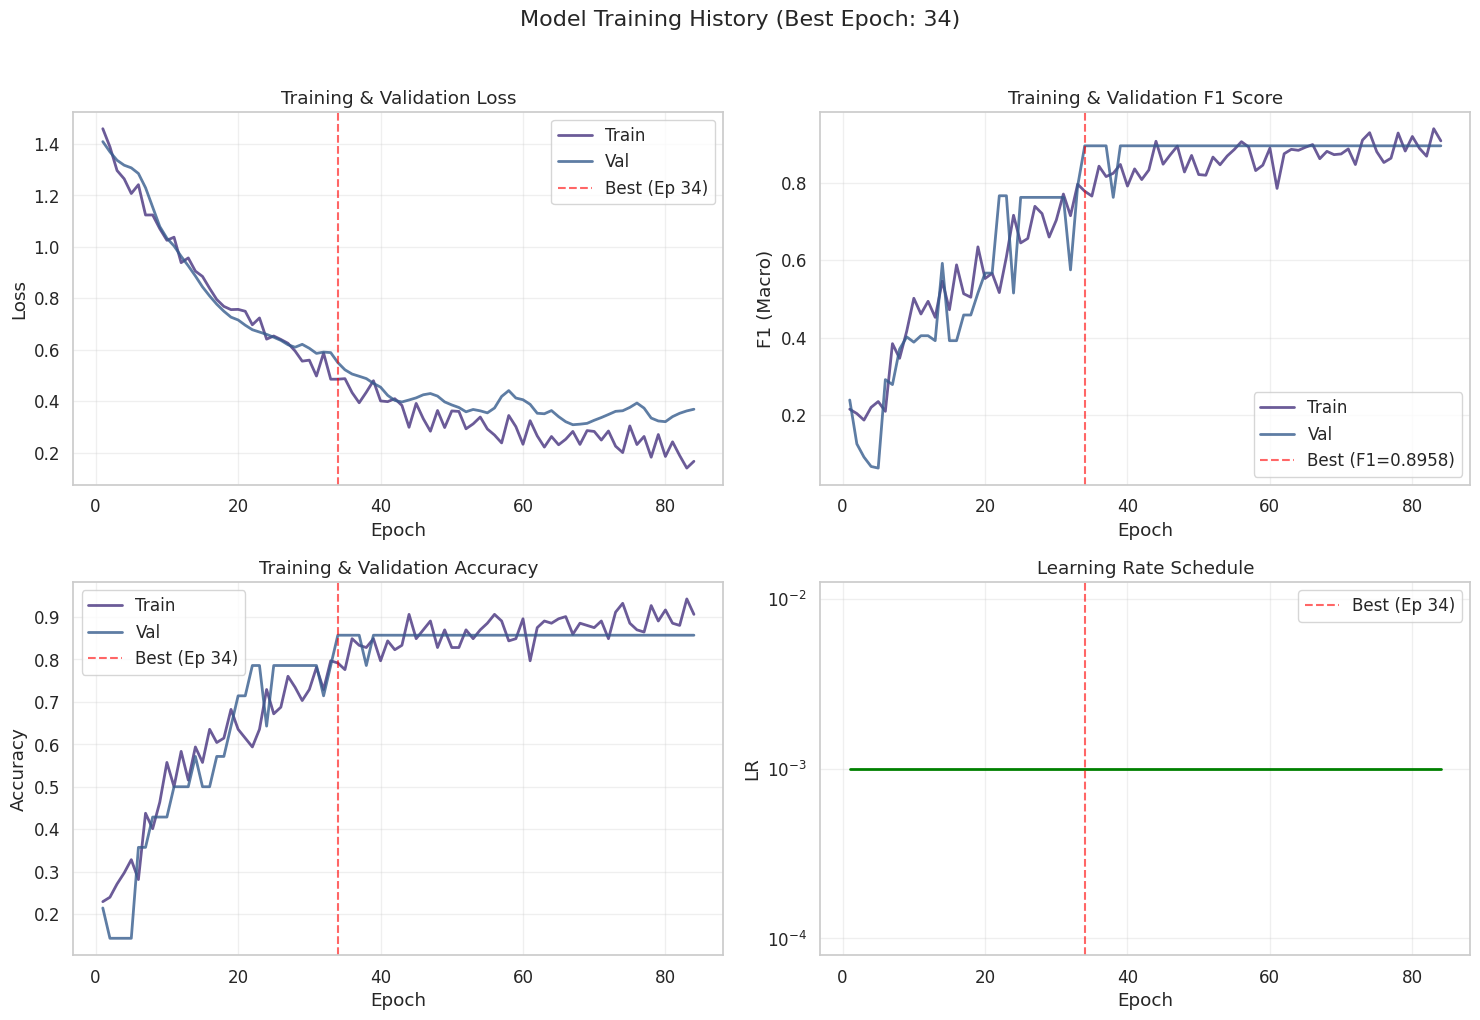

   📊 Saved: /kaggle/working/results/plots/training_curves.png

📥 Loading model for evaluation...
   Loaded model from epoch 34 (Val F1=0.8958)

📋 TEST SET EVALUATION RESULTS
                          precision    recall  f1-score   support

                 Healthy       0.67      1.00      0.80         4
        Hydraulic_Stress       0.50      1.00      0.67         2
Nutrient_Chemical_Stress       1.00      0.33      0.50         3
       High_Disease_Risk       1.00      0.67      0.80         6

                accuracy                           0.73        15
               macro avg       0.79      0.75      0.69        15
            weighted avg       0.84      0.73      0.72        15

Accuracy:       0.7333
F1 (macro):     0.6917
F1 (weighted):  0.7222
Mean AP:        0.9375
Latency:        2.06 ms (p95: 2.40 ms)

📊 Generating evaluation plots...


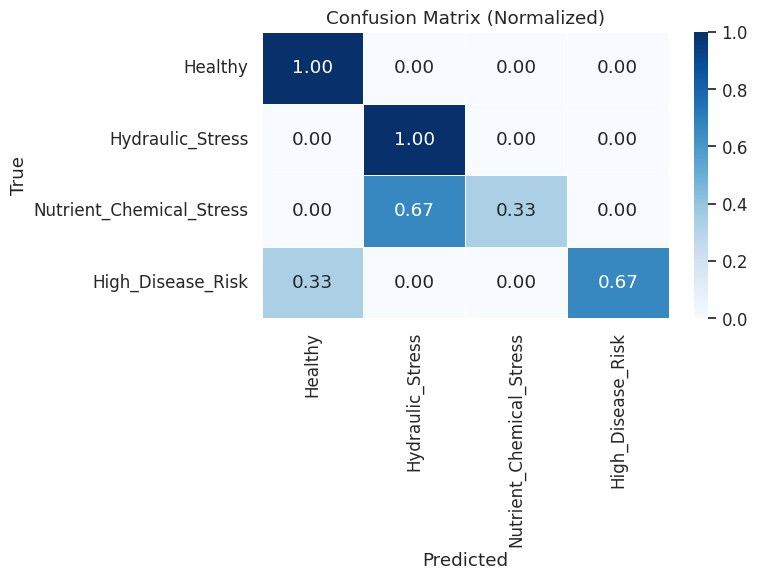

   📊 Saved: /kaggle/working/results/plots/confusion_matrix_norm.png


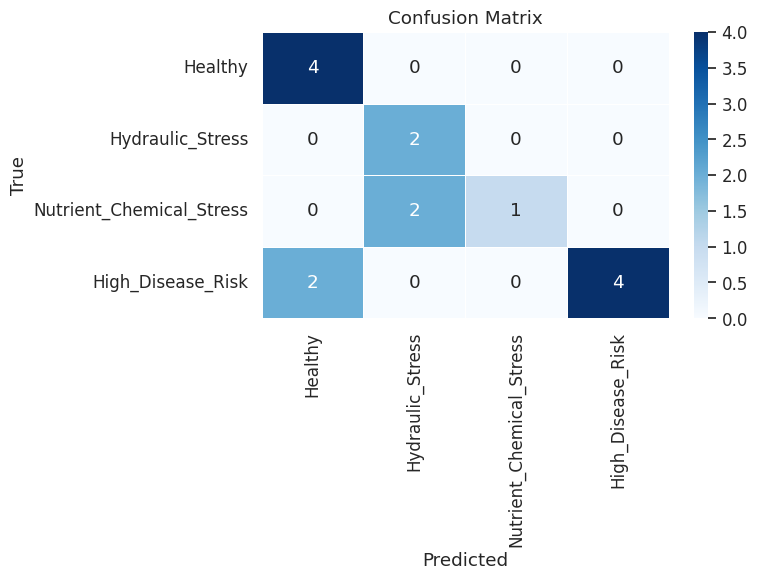

   📊 Saved: /kaggle/working/results/plots/confusion_matrix_raw.png


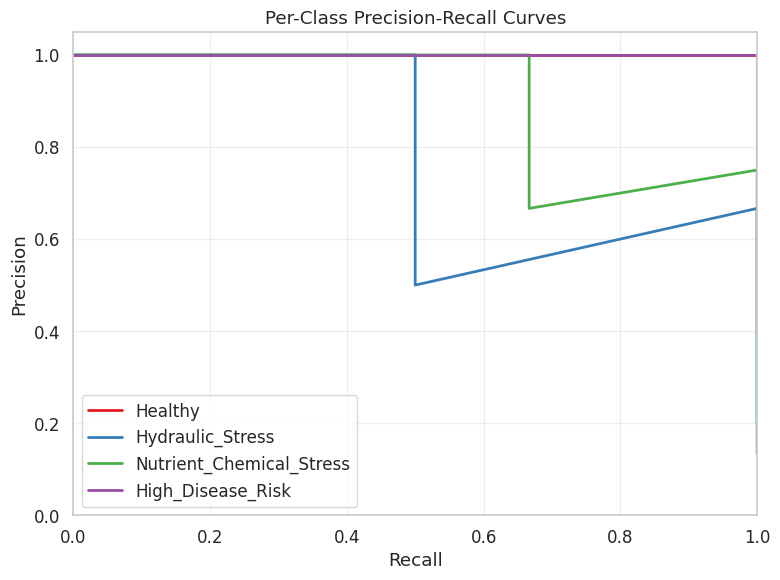

   📊 Saved: /kaggle/working/results/plots/pr_curves.png

🔍 Running explainability analysis...
   → Extracting attention maps...
   Attention-based feature importance:
            air_temp: █████████████ 0.2727
        battery_volt: ████████ 0.1770
            hour_cos: ████████ 0.1717
            hour_sin: ███████ 0.1528
           light_lux: ████ 0.0811
           water_tds: ████ 0.0801
       soil_moisture: █ 0.0397
           soil_temp: █ 0.0250
             soil_ph:  0.0000
            humidity:  0.0000

   → Computing Integrated Gradients...

   Integrated Gradients feature importance:
            air_temp: █████████ 0.1933
        battery_volt: █████████ 0.1842
           soil_temp: ███████ 0.1476
            hour_sin: ██████ 0.1307
            hour_cos: █████ 0.1012
           light_lux: ████ 0.0842
       soil_moisture: ████ 0.0830
           water_tds: ███ 0.0757
             soil_ph:  0.0000
            humidity:  0.0000

📊 Generating explainability plots...


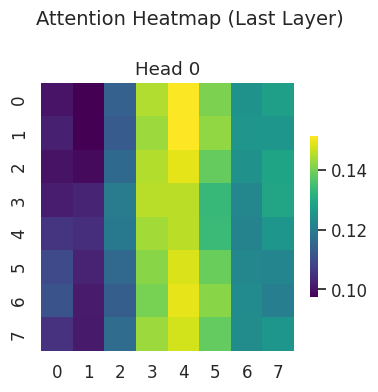

   📊 Saved: /kaggle/working/results/plots/attention_heatmap.png


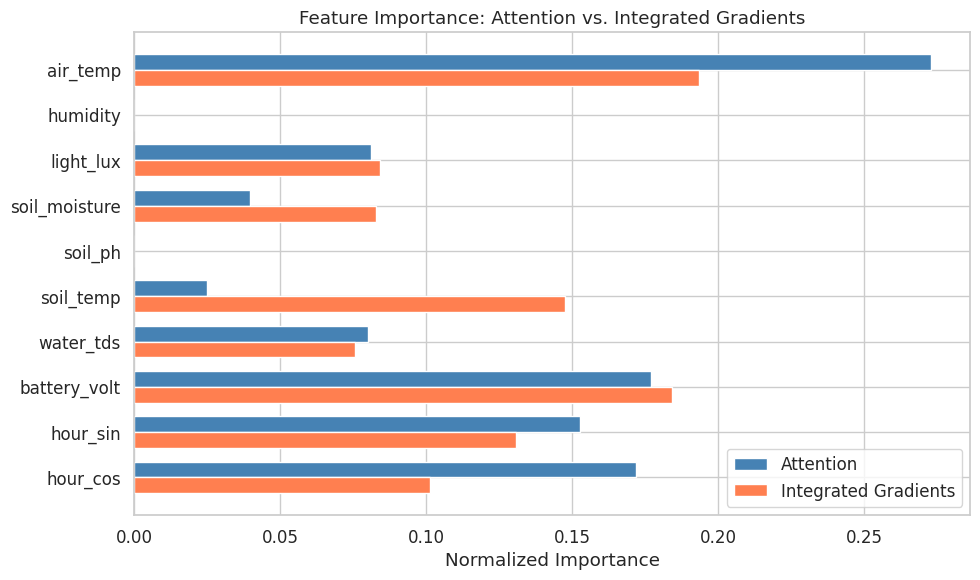

   📊 Saved: /kaggle/working/results/plots/feature_importance_comparison.png


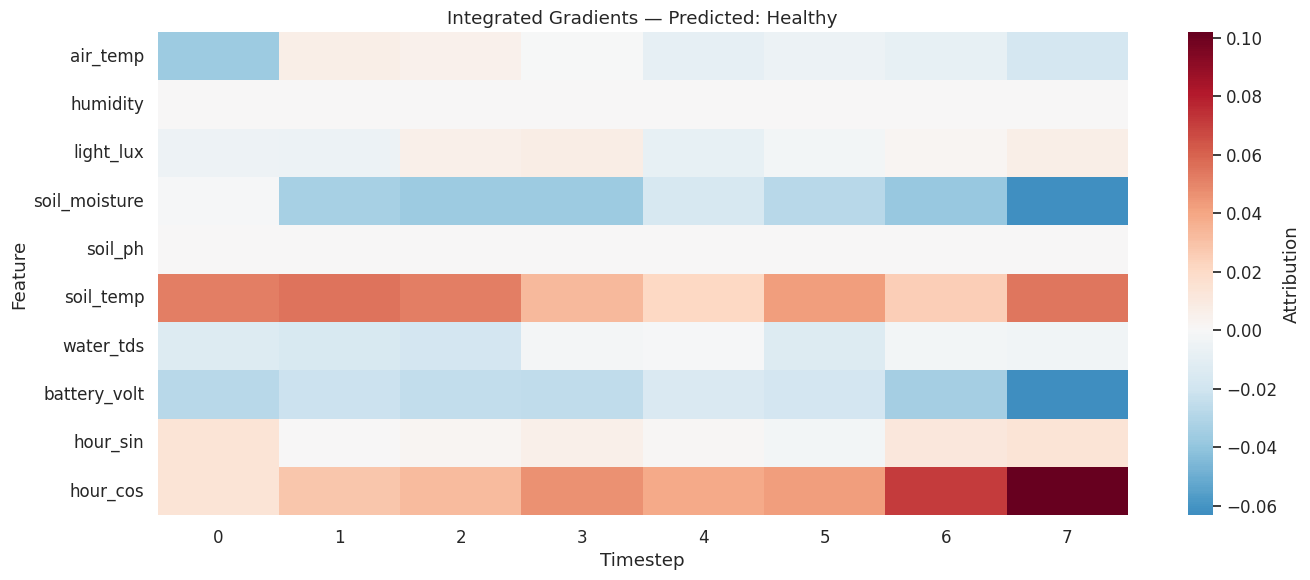

   📊 Saved: /kaggle/working/results/plots/ig_attributions.png

🎉 PIPELINE COMPLETE!
   Test Accuracy:  0.7333
   Test F1 (macro): 0.6917
   Plots saved to: /kaggle/working/results/plots
   Checkpoints:    /kaggle/working/checkpoints


In [43]:
def main():
    """
    Complete end-to-end pipeline.
    Run this function or copy individual sections into notebook cells.
    """
    
    # Step 1: labels on RAW data
    df = load_and_merge_sensors()

    # Step 2: Generate Labels
    labels = generate_labels(df)
    
    # Step 3: scaling and SPLITTING (now includes stratified window split & augmentation)
    splits, scaler, feature_columns = preprocess_pipeline(df, labels)
    
    # Step 4: compute class weights  
    class_weights = compute_class_weights(labels)
    input_dim = len(feature_columns)

    # Step 5: DataLoaders
    loaders = create_dataloaders(splits)
    
    if len(loaders["train"]) == 0:
        print("\n❌ ERROR: Training cannot proceed because the training set is empty.")
        print(f"   The current dataset has {len(df)} total timesteps.")
        print(f"   With WINDOW_SIZE={WINDOW_SIZE}, you need at least {WINDOW_SIZE} consecutive timesteps in the training split.")
        print("   Please check your data files or reduce WINDOW_SIZE in Section 1.")
        return

    # Step 6: Build Model
    print(f"\n🧠 Building Transformer-LSTM (input_dim={input_dim})...")
    model = TransformerLSTM(input_dim=input_dim)

    # Step 7: Train
    history = train_model(model, loaders["train"], loaders["val"], class_weights)

    # Step 8: Training Curves
    plot_training_curves(history)

    # Step 9: Load Best Model & Evaluate
    print("\n📥 Loading model for evaluation...")
    best_path = CHECKPOINTS_DIR / "best_model.pt"
    if not best_path.exists():
        best_path = CHECKPOINTS_DIR / "last_model.pt"
    
    if not best_path.exists():
        print("   ❌ ERROR: No model checkpoints found! (Training may have failed)")
        return

    checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"   Loaded model from epoch {checkpoint['epoch']} (Val F1={checkpoint.get('val_f1', 0.0):.4f})")

    metrics, y_true, y_pred, y_prob = evaluate_model(model, loaders["test"])

    # Step 10: Evaluation Plots
    print("\n📊 Generating evaluation plots...")
    cm = np.array(metrics["confusion_matrix"])
    plot_confusion_matrix(cm, normalize=True)
    plot_confusion_matrix(cm, normalize=False)
    if "pr_curves" in metrics:
        plot_precision_recall_curves(metrics["pr_curves"])

    # Step 11: Explainability
    attn_imp, ig_imp = run_explainability(model, loaders["test"], feature_columns)

    # Step 12: Explainability Plots
    print("\n📊 Generating explainability plots...")
    plot_attention_heatmap(model, loaders["test"])
    plot_feature_importance_comparison(attn_imp, ig_imp)
    plot_ig_attribution_heatmap(model, loaders["test"], feature_columns)

    # DONE
    print("\n" + "=" * 60)
    print("🎉 PIPELINE COMPLETE!")
    print(f"   Test Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Test F1 (macro): {metrics['f1_macro']:.4f}")
    print(f"   Plots saved to: {RESULTS_DIR / 'plots'}")
    print(f"   Checkpoints:    {CHECKPOINTS_DIR}")
    print("=" * 60)


# ── Run ──
if __name__ == "__main__":
    main()